In [1]:
#import scvi
import scanpy as sc
import anndata as ad
#import torch
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
from datetime import datetime
import glob
from scipy.sparse import csr_matrix

In [2]:
# 0: config (later we will outsource this part to yaml, for now we will continue selecting all variables here)
sc._settings.ScanpyConfig.n_jobs = os.cpu_count() - 2

# 1: Variables for Data loading and set-up
sample_id            = 'All_samples' 
sample               = 'All_samples'
#sample               = sample_to_injury[orig_to_srr[sample_id.split('_')[-1]]] + '_' + sample_id

working_dir          = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/results/LemonTree/noProteomics_percentile2_divide_by_sum/single_cell/'
base_dir             = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/results/LemonTree/noProteomics_percentile2_divide_by_sum/'
data_dir             = '/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/data/single_cell'
result_folder        = working_dir+sample+'/'
result_file_name     = sample#.h5ad'

In [3]:
# 1: Data loading and set-up

## change settings in the sc module for verbosity, logging and figures
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

## make missing folders
os.makedirs(working_dir, exist_ok=True)
os.makedirs(result_folder, exist_ok=True)
os.makedirs(result_folder+'/hd5', exist_ok=True)
os.makedirs(result_folder+'/QC', exist_ok=True)
os.makedirs(result_folder+'/figures', exist_ok=True)


## change to working directory
os.chdir(working_dir)
results_file = result_file_name  # the file that will store the analysis results

In [4]:
# read h5ad file all_samples_6000HVG_annotated.h5ad
adata = sc.read_h5ad(data_dir + '/All_samples_scANVI_annotated.h5ad')
adata

AnnData object with n_obs × n_vars = 45144 × 27632
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'total_counts_mt', 'pct_counts_mt', 'sample_id', 'author', '_scvi_batch', 'labels_scanvi', '_scvi_labels', 'predictions_scanvi'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_scANVI'

In [5]:
adata.layers['raw'] = adata.X.copy()

In [6]:
# Normalize the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print(adata.X.max())

normalizing counts per cell
    finished (0:00:00)
8.868731809091818


computing neighbors


/home/borisvdm/Software/miniconda3/envs/single-cell/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:19)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:19)


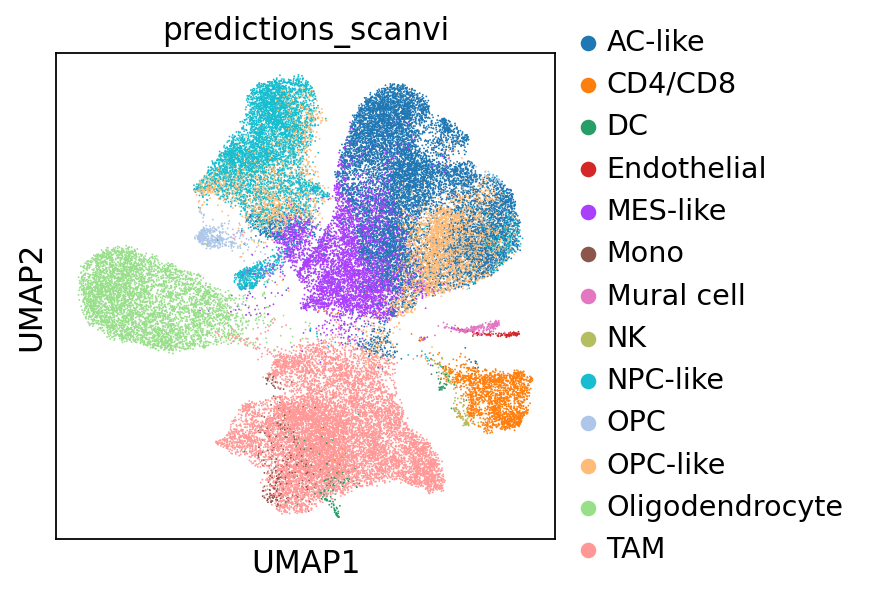

In [7]:
# Calculate UMAP on X_scANVI
sc.pp.neighbors(adata, use_rep='X_scANVI')
sc.tl.umap(adata)
# Visualize umap on X_scANVI
sc.pl.umap(adata, color=['predictions_scanvi'], wspace=0.4, save='_celltype_sample.png', show=True)

In [8]:
# Read file with gene modules from LemonTree
gene_modules = pd.read_csv('/home/borisvdm/Documents/PhD/thesis_Mirte/Wang2021/results/LemonTree/noProteomics_percentile2_divide_by_sum/ModuleViewer_files/clusters_list.txt', sep = '\t', header=None)
# set column names 'Module', 'Genes'
gene_modules.columns = ['Module', 'Genes']
# create dict from Module to list of genes, split Genes column on |
gene_module_dict = {}
for index, row in gene_modules.iterrows():
    gene_module_dict[row['Module']] = row['Genes'].split('|')

print(gene_module_dict)

{0: ['VSTM2L', 'GABRA5', 'SYT4', 'CREG2', 'SYNGR3', 'RBFOX1', 'KCNS1', 'SYP', 'GPR83', 'PRSS3', 'STX1B', 'TGFBR3L', 'GLT1D1', 'AK5', 'SPTB', 'C4orf50', 'VIPR1', 'TMEM130', 'IQSEC3', 'SYN1', 'CHD5', 'GREM2', 'SYT7', 'PRMT8', 'KCNJ4', 'HPCAL4', 'GABRD', 'ADAM11', 'EPHB6', 'KCTD16', 'GALNTL6', 'RASAL1', 'SLC17A7', 'CPLX1', 'DOC2A', 'GPR61', 'PACSIN1', 'GABRB2', 'PCP4L1', 'ARHGDIG', 'TMEM155', 'CABP1', 'CAMK2A', 'NRGN', 'DLGAP3', 'SNAP25', 'DDN', 'MTUS2', 'CACNA1B', 'GNG3', 'MPPED1', 'SLC6A17', 'SNCB', 'SLC6A7', 'SLC8A2', 'VWA5B2', 'PPP2R2C', 'SV2C', 'CALY', 'SLC30A3', 'SLC12A5', 'HPCA', 'NEFM', 'MAS1', 'CPNE6', 'C1QTNF4', 'UNC5A', 'AJAP1', 'SYT5', 'MFSD4', 'STYK1', 'GLS2', 'KIAA1644', 'ICAM5', 'ATP8A2', 'NEURL1', 'KIAA1045', 'ATP2B3', 'SYN2', 'CAMK1G', 'CRYM', 'MAP7D2', 'PHYHIP', 'FSTL4', 'TRHDE', 'RTN4RL1', 'PSD', 'RYR2'], 1: ['GAD2', 'CACNG3', 'GJD2', 'NWD2', 'PCSK2', 'SYNPR', 'GABRG2', 'WSCD2', 'FADS6', 'GABRG3', 'KLHL1', 'CCK', 'GPR26', 'MYT1L', 'EPHA6', 'LRTM2', 'HCN1', 'SLC32A1', 'G

In [9]:
# Filter gene modules to only include modules that have passed coherence filtering
specific_modules = pd.read_csv(base_dir+'Networks/specific_modules.txt', header = None)
specific_modules
# retrieve list of modules_to_keep
modules_to_keep = specific_modules[0].to_list()
modules_to_keep
# filter modules: only keep keys in gene_module_dict that match modules_to_keep
gene_module_dict = {k: v for k, v in gene_module_dict.items() if k in modules_to_keep}
print(f'Keeping {len(gene_module_dict)} modules after filtering for coherence: {list(gene_module_dict.keys())}')

Keeping 46 modules after filtering for coherence: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 20, 21, 23, 24, 26, 29, 30, 33, 36, 37, 39, 40, 41, 42, 43, 45, 46, 47, 48, 50, 51, 53, 54, 56, 57, 60, 61, 62]


In [10]:
# Calculate module scores using scanpy
# First, let's track which genes are available in the dataset
total_genes = 0
found_genes = 0
module_gene_counts = {}

print("Checking gene availability in dataset...")
for module, genes in gene_module_dict.items():
    available_genes = [gene for gene in genes if gene in adata.var_names]
    missing_genes = [gene for gene in genes if gene not in adata.var_names]
    
    total_genes += len(genes)
    found_genes += len(available_genes)
    module_gene_counts[module] = {
        'total': len(genes),
        'found': len(available_genes),
        'missing': len(missing_genes),
        'available_genes': available_genes
    }

    # warning if less than 50% of genes are found
    if len(available_genes) < len(genes) / 2:
        print(f"Warning: Module {module} has less than 50% of its genes available in the dataset ({len(available_genes)}/{len(genes)})")
    
    #print(f"Module {module}: {len(available_genes)}/{len(genes)} genes found ({len(missing_genes)} missing)")

print(f"\nOverall statistics:")
print(f"Total genes across all modules: {total_genes}")
print(f"Found genes: {found_genes} ({found_genes/total_genes*100:.1f}%)")
print(f"Missing genes: {total_genes-found_genes} ({(total_genes-found_genes)/total_genes*100:.1f}%)")

# Calculate module scores using scanpy for each module that has available genes
print("\nCalculating module scores using scanpy...")
modules_with_genes = []

for module, gene_info in module_gene_counts.items():
    if gene_info['found'] > 0:  # Only process modules with at least some genes
        available_genes = gene_info['available_genes']
        #print(f"Available genes for module {module}: {available_genes}")
        score_name = f'module_{module}_score'
        
        # Calculate module score using scanpy
        sc.tl.score_genes(adata, available_genes, score_name=score_name, use_raw=False)
        modules_with_genes.append(module)
        #print(f"Calculated score for module {module} using {len(available_genes)} genes")

    else:
        print(f"Skipping module {module} - no genes available")


print(f"\nModule scores calculated for {len(modules_with_genes)} modules")

# Create list of score column names for plotting
module_score_names = [f'module_{module}_score' for module in modules_with_genes]

print(f"Module scores summary:")
print(f"  Modules: {len(modules_with_genes)}")
print(f"  Cell types: {len(adata.obs['predictions_scanvi'].unique())}")
print(f"  Total genes used: {found_genes}")

# Create summary table showing module statistics
module_stats_df = pd.DataFrame.from_dict(module_gene_counts, orient='index')
module_stats_df = module_stats_df.drop('available_genes', axis=1)  # Remove the gene list column
module_stats_df['gene_coverage'] = module_stats_df['found'] / module_stats_df['total'] * 100

print("\nModule gene coverage summary:")
print(module_stats_df.round(1))

Checking gene availability in dataset...

Overall statistics:
Total genes across all modules: 1930
Found genes: 1790 (92.7%)
Missing genes: 140 (7.3%)

Calculating module scores using scanpy...
computing score 'module_0_score'
    finished: added
    'module_0_score', score of gene set (adata.obs).
    745 total control genes are used. (0:00:00)
computing score 'module_1_score'
    finished: added
    'module_1_score', score of gene set (adata.obs).
    748 total control genes are used. (0:00:00)
computing score 'module_2_score'
    finished: added
    'module_2_score', score of gene set (adata.obs).
    898 total control genes are used. (0:00:00)
computing score 'module_3_score'
    finished: added
    'module_3_score', score of gene set (adata.obs).
    648 total control genes are used. (0:00:00)
computing score 'module_4_score'
    finished: added
    'module_4_score', score of gene set (adata.obs).
    748 total control genes are used. (0:00:00)
computing score 'module_5_score'
   

Creating scanpy plots with clustered modules...
Original module order: ['module_0_score', 'module_1_score', 'module_2_score', 'module_3_score', 'module_4_score', 'module_5_score', 'module_6_score', 'module_7_score', 'module_8_score', 'module_9_score', 'module_10_score', 'module_11_score', 'module_12_score', 'module_13_score', 'module_14_score', 'module_15_score', 'module_17_score', 'module_18_score', 'module_20_score', 'module_21_score', 'module_23_score', 'module_24_score', 'module_26_score', 'module_29_score', 'module_30_score', 'module_33_score', 'module_36_score', 'module_37_score', 'module_39_score', 'module_40_score', 'module_41_score', 'module_42_score', 'module_43_score', 'module_45_score', 'module_46_score', 'module_47_score', 'module_48_score', 'module_50_score', 'module_51_score', 'module_53_score', 'module_54_score', 'module_56_score', 'module_57_score', 'module_60_score', 'module_61_score', 'module_62_score']
Clustered module order: ['module_39_score', 'module_61_score', '

/tmp/ipykernel_222274/527083703.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


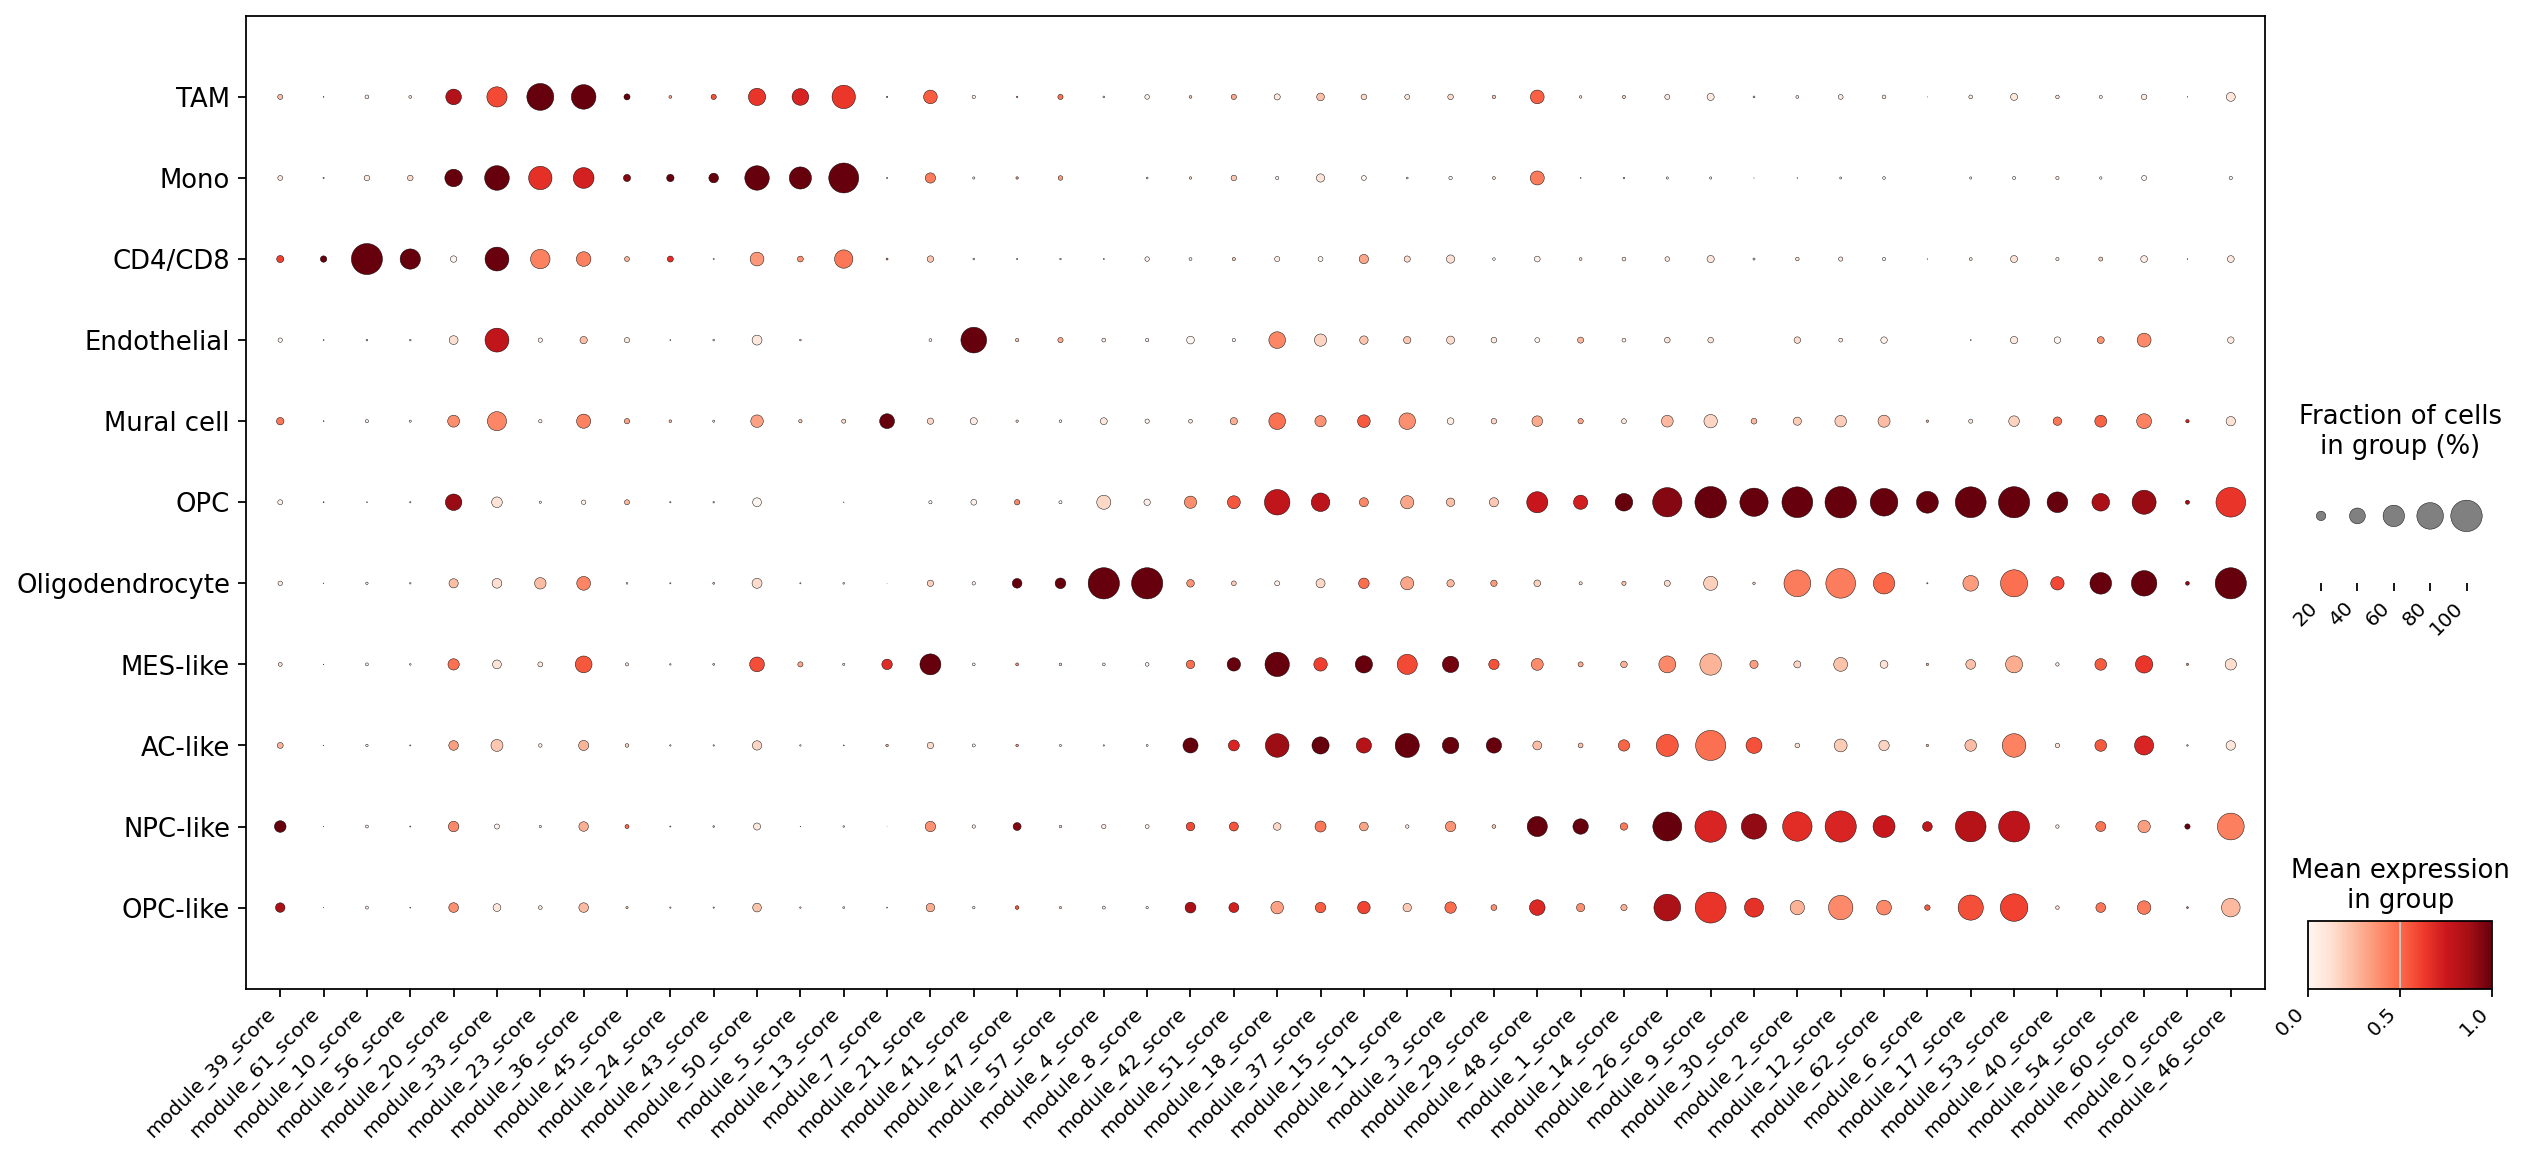

✓ Dotplot with clustered modules saved


In [11]:
# Create scanpy plots for module scores with clustered modules
print("Creating scanpy plots with clustered modules...")

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Define custom cell type order
cell_type_order = [
    'TAM', 'Mono', 'CD4/CD8', 'Endothelial', 'Mural cell', 'OPC',
    'Oligodendrocyte', 'MES-like', 'AC-like', 'NPC-like', 'OPC-like'
]

# Filter adata to only include cell types in the order list and reorder
adata_ordered = adata[adata.obs['predictions_scanvi'].isin(cell_type_order)].copy()
adata_ordered.obs['predictions_scanvi'] = pd.Categorical(
    adata_ordered.obs['predictions_scanvi'],
    categories=cell_type_order,
    ordered=True
)

# Create a matrix for clustering: rows = modules, columns = cell types
# Calculate mean expression of each module in each cell type
module_celltype_matrix = []
for module_name in module_score_names:
    # Get mean expression per cell type
    mean_expr = adata_ordered.obs.groupby('predictions_scanvi', observed=True)[module_name].mean()
    # Reorder to match cell_type_order
    mean_expr_ordered = [mean_expr[ct] if ct in mean_expr.index else 0 for ct in cell_type_order]
    module_celltype_matrix.append(mean_expr_ordered)

# Convert to DataFrame for clustering
module_matrix_df = pd.DataFrame(
    module_celltype_matrix, 
    index=module_score_names,
    columns=cell_type_order
)

# Perform hierarchical clustering on modules
linkage_matrix = linkage(module_matrix_df, method='average', metric='correlation')

# Get clustered module order
from scipy.cluster.hierarchy import leaves_list
cluster_order = leaves_list(linkage_matrix)
clustered_module_names = [module_score_names[i] for i in cluster_order]

print(f"Original module order: {module_score_names}")
print(f"Clustered module order: {clustered_module_names}")

# Create dotplot with clustered module order
dotplot = sc.pl.dotplot(
    adata_ordered,
    clustered_module_names,  # Use clustered order
    groupby="predictions_scanvi",
    dendrogram=False,  # Don't cluster cell types
    standard_scale="var",
    save=None,
    show=False,
    figsize=(18, 8)
)

# Rotate x-axis labels
for ax in plt.gcf().axes:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")
        label.set_fontsize(9)

plt.tight_layout()

plt.savefig(result_folder + f'/figures/module_scores_dotplot_{sample}_clustered.png', dpi=300)
plt.show()

print(f"✓ Dotplot with clustered modules saved")

Creating transposed dotplot with modules on y-axis...


/tmp/ipykernel_222274/1787353863.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


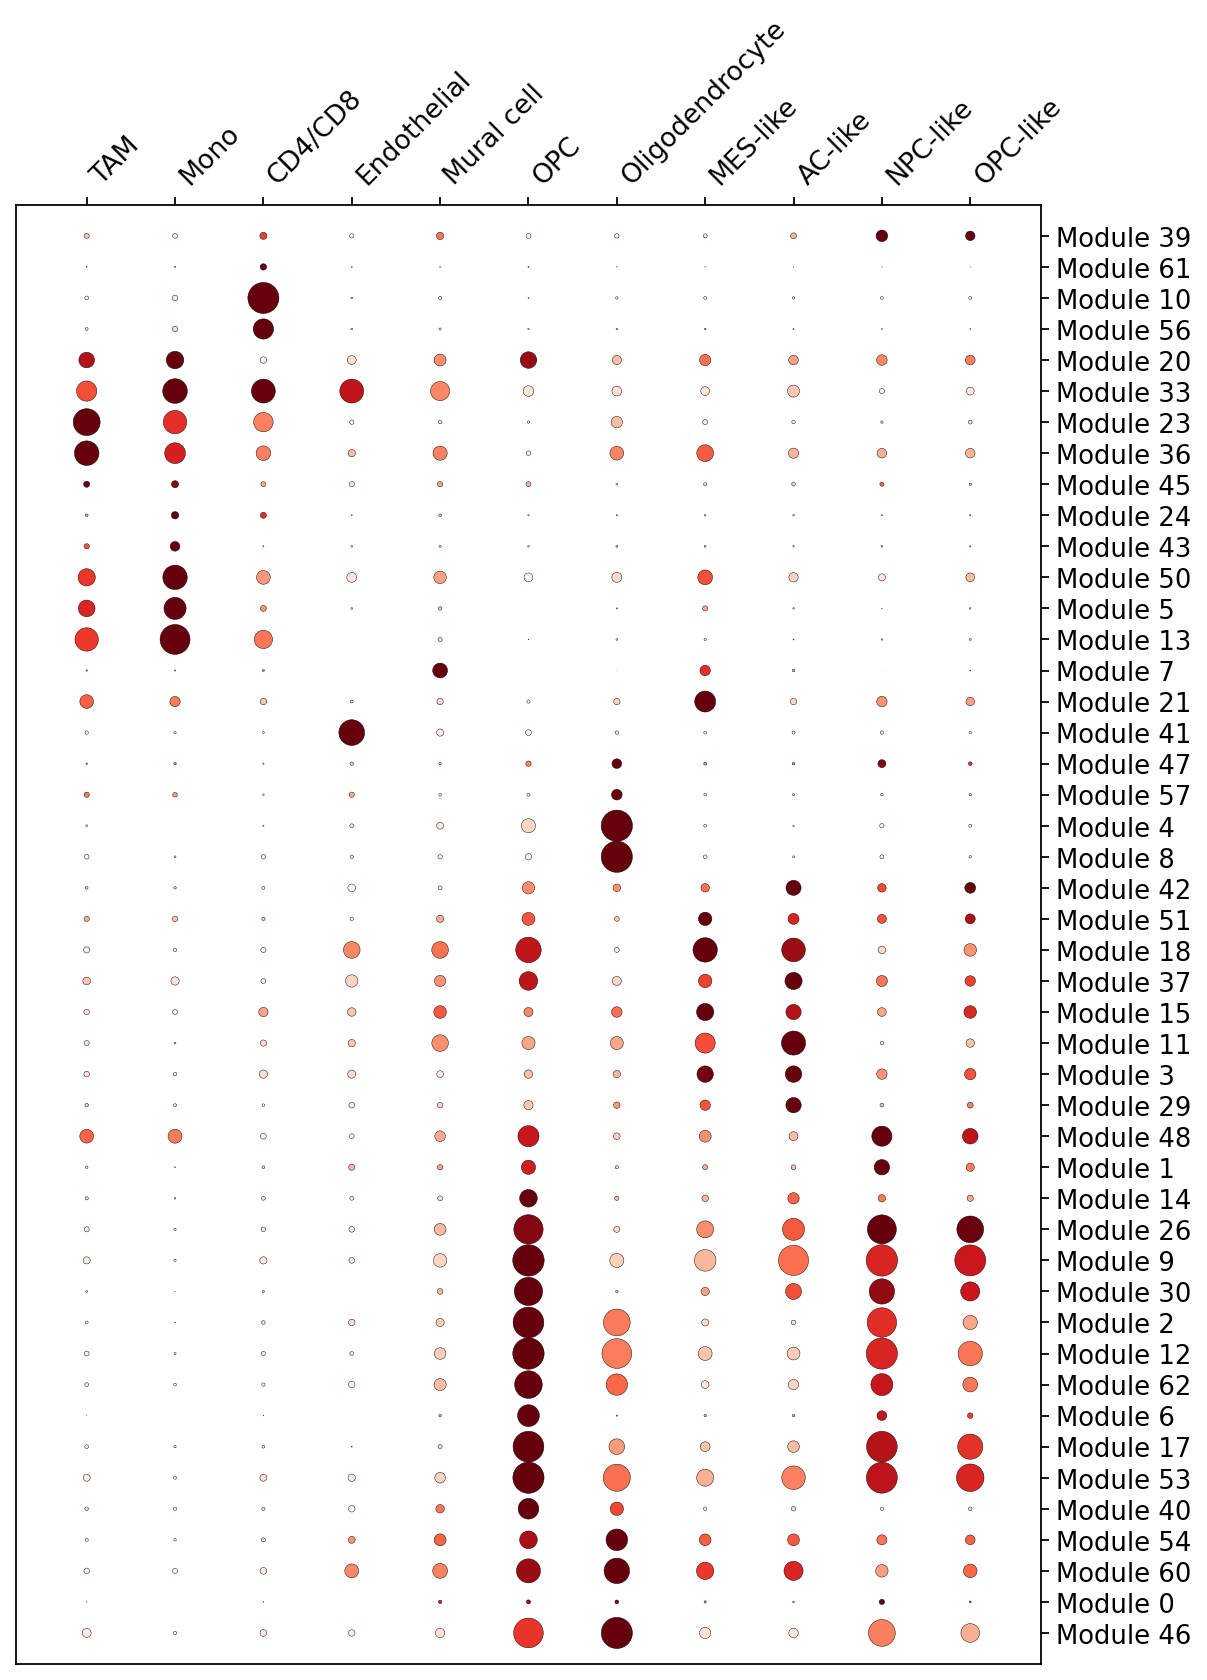

✓ Transposed dotplot saved


In [12]:
# Create transposed dotplot with modules as rows and cell types as columns
print("Creating transposed dotplot with modules on y-axis...")

# Create dotplot with swapped axes
dotplot_transposed = sc.pl.dotplot(
    adata_ordered,
    clustered_module_names,  # Use clustered order
    groupby="predictions_scanvi",
    dendrogram=False,
    standard_scale="var",
    save=None,
    show=False,
    figsize=(10, 12),
    swap_axes=True  # This transposes the plot
)

# Customize axis positions
fig = plt.gcf()

# Identify and remove legend/colorbar axes (typically the rightmost axes in scanpy dotplot)
# The main plot axes is usually axes[0], and legend/colorbar axes are axes[1] and axes[2]
axes_to_keep = []
main_ax = None

for i, ax in enumerate(fig.axes):
    # The main plot axis has both x and y tick labels
    if len(ax.get_xticklabels()) > 0 and len(ax.get_yticklabels()) > 0:
        main_ax = ax
        axes_to_keep.append(ax)
    else:
        # This is likely a legend/colorbar axis - make it invisible
        ax.set_visible(False)

# Now customize the main axis
if main_ax is not None:
    # Move x-axis labels to top
    main_ax.xaxis.tick_top()
    main_ax.xaxis.set_label_position('top')
    for label in main_ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("left")
        label.set_fontsize(12)  # Increased font size
    
    # Move y-axis labels to right and remove '_score' suffix
    main_ax.yaxis.tick_right()
    main_ax.yaxis.set_label_position('right')
    # Remove '_score' from y-axis labels
    new_labels = [label.get_text().replace('_score', '') for label in main_ax.get_yticklabels()]
    # capitalize
    new_labels = [re.sub(r'module_(\d+)', r'Module \1', label) for label in new_labels]
    main_ax.set_yticklabels(new_labels)

plt.tight_layout()

plt.savefig(result_folder + f'/figures/module_scores_dotplot_{sample}_clustered_transposed.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Transposed dotplot saved")